<a href="https://colab.research.google.com/github/mftaa/Pengolahan_Citra/blob/main/jobsheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#JOBSHEET 05: MENGUKUR KEMIRIPAN CITRA DAN  PENERAPANNYA DALAM PENGENALAN POLA
#Miftachussurur - 4.33.23.1.15

##Praktikum 1. Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)

jarak euclidean antara patch1 dan patch2 : 24.7650
jarak euclidean antara patch1 dan patch3 : 5.0000
jarak manhattan antara patch1 dan patch2 : 936.4392
jarak manhattan antara patch1 dan patch3 : 250.0000


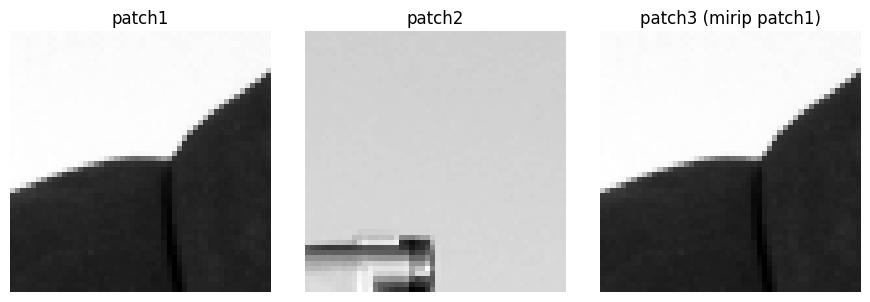

In [ ]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]
patch3 = patch1 + 0.1
patch3 = np.clip(patch3, 0 , 1)

vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

dist_12_12 = distance.euclidean(vec1, vec2)
dist_12_13 = distance.euclidean(vec1, vec3)

dist_11_12 = distance.cityblock(vec1, vec2)
dist_11_13 = distance.cityblock(vec1, vec3)

print(f"jarak euclidean antara patch1 dan patch2 : {dist_12_12:.4f}")
print(f"jarak euclidean antara patch1 dan patch3 : {dist_12_13:.4f}")
print(f"jarak manhattan antara patch1 dan patch2 : {dist_11_12:.4f}")
print(f"jarak manhattan antara patch1 dan patch3 : {dist_11_13:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(9,3))
axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('patch1')
axes[0].axis('off')
axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('patch2')
axes[1].axis('off')
axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('patch3 (mirip patch1)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

##Praktikum 2. Menghitung Cosine Similarity antara Histogram Warna

Cosine similarity antara image 1 (Astronout) dan image 2 (Coffee) : 0.8156
Cosine similarity antara image 1 (Astronout) dan image 3 (Astronout) : 1.0000
Cosine similarity antara image 1 (Astronout) dan image 4 (Astronout downsampled) : 1.0000


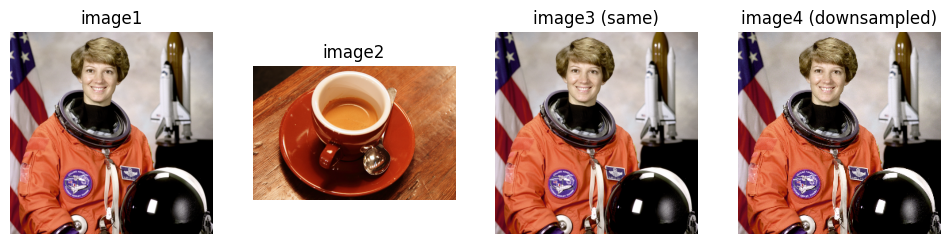

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte, io, color
from scipy.spatial import distance

def calculate_rgb_histogram(image, bins=16):
  img_uint8 = img_as_ubyte(image)
  hist_r = np.histogram(img_uint8[:, :, 0].ravel(), bins=bins, range=(0, 256))
  hist_g = np.histogram(img_uint8[:, :, 1].ravel(), bins=bins, range=(0, 256))
  hist_b = np.histogram(img_uint8[:, :, 2].ravel(), bins=bins, range=(0, 256))

  hist_combined = np.concatenate((hist_r[0], hist_g[0], hist_b[0]))
  hist_combined = hist_combined.astype(float) / np.sum(hist_combined)
  return hist_combined

try:
  image1 = data.astronaut()
  image2 = data.coffee()
  image3 = data.astronaut()
  image4 = image1[::2, ::2, :]
except Exception as e:
  print(f"Gagal memuat data skimage: {e}. Membuat citra dummy")
  image1 = np.random.rand(100, 100, 3)
  image2 = np.random.rand(100, 100, 3) * 0.5
  image3 = image1.copy()
  image4 = image1[::2, ::2, :]

hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

print(f"Cosine similarity antara image 1 (Astronout) dan image 2 (Coffee) : {sim_12:.4f}")
print(f"Cosine similarity antara image 1 (Astronout) dan image 3 (Astronout) : {sim_13:.4f}")
print(f"Cosine similarity antara image 1 (Astronout) dan image 4 (Astronout downsampled) : {sim_14:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(image1); axes[0].set_title('image1'); axes[0].axis('off')
axes[1].imshow(image2); axes[1].set_title('image2'); axes[1].axis('off')
axes[2].imshow(image3); axes[2].set_title('image3 (same)'); axes[2].axis('off')
axes[3].imshow(image4); axes[3].set_title('image4 (downsampled)'); axes[3].axis('off')
plt.show()

##Praktikum 3. Menghitung Structural Similarity Index (SSIM)

SSIM (ref vs same): 1.0000
SSIM (ref vs noisy): 0.2952
SSIM (ref vs contrast): 0.9651
SSIM (ref vs blurred): 0.8027


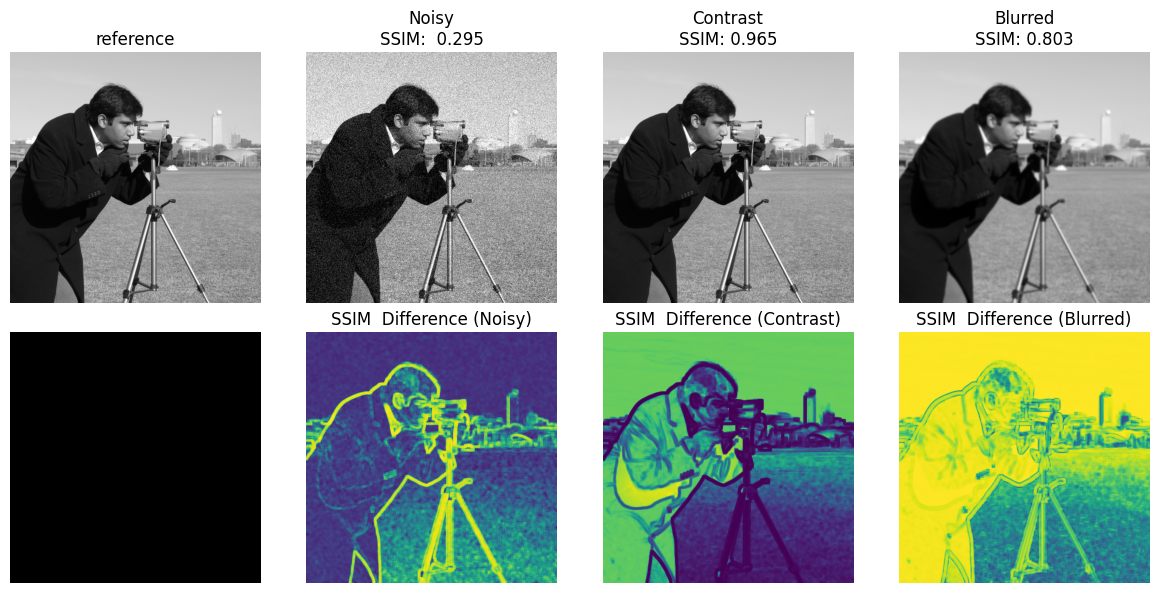

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from skimage.util import random_noise

image_ref = img_as_float(data.camera())

image_same = image_ref.copy()

image_noisy = random_noise(image_ref, mode='gaussian', var = 0.01)
image_contrast = np.clip(image_ref * 0.8, 0, 1)
from skimage.filters import gaussian
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None)

data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)

print(f"SSIM (ref vs same): {ssim_same:.4f}")
print(f"SSIM (ref vs noisy): {ssim_noisy:.4f}")
print(f"SSIM (ref vs contrast): {ssim_contrast:.4f}")
print(f"SSIM (ref vs blurred): {ssim_blurred:.4f}")

fig,axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()
ax[0].imshow(image_ref, cmap='gray'); ax[0].set_title('reference'); ax[0].axis('off')
ax[1].imshow(image_noisy, cmap='gray'); ax[1].set_title('noisy'); ax[1].set_title(f'Noisy\nSSIM:  {ssim_noisy:.3f}'); ax[1].axis('off')
ax[2].imshow(image_contrast, cmap='gray'); ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}'); ax[2].axis('off')
ax[3].imshow(image_blurred, cmap='gray');  ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}'); ax[3].axis('off')
ax[4].imshow(np.zeros_like(image_ref), cmap='gray');  ax[4].set_title(''); ax[4].axis('off')
ax[5].imshow(diff_noisy, cmap='viridis'); ax[5].set_title('SSIM  Difference (Noisy)'); ax[5].axis('off')
ax[6].imshow(diff_contrast, cmap='viridis'); ax[6].set_title('SSIM  Difference (Contrast)'); ax[6].axis('off')
ax[7].imshow(diff_blurred, cmap='viridis'); ax[7].set_title('SSIM  Difference (Blurred)'); ax[7].axis('off')

plt.tight_layout()
plt.show()


##Praktikum 4. Penerapan Template Matching

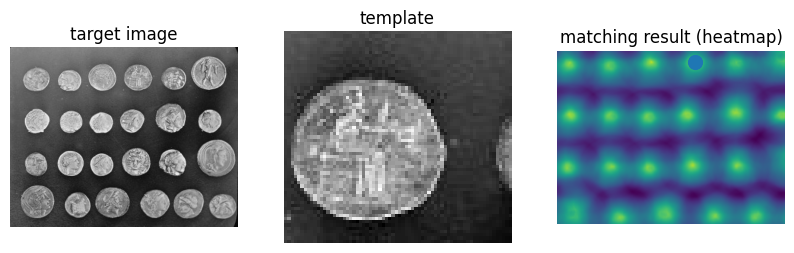

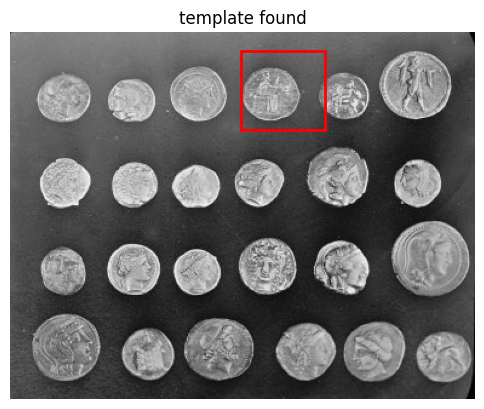

template ditemikan di koordinat (x,y): (190,15)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

image = data.coins()
template = image[15:80, 190:260]
result = match_template(image, template)

ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('target image')
ax[0].set_axis_off()
ax[1].imshow(template, cmap='gray')
ax[1].set_title('template')
ax[1].set_axis_off()
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('matching result (heatmap)')
ax[2].set_axis_off()
ax[2].plot(x, y, 'o', markersize=10)

fig2, ax_main = plt.subplots(figsize=(6,6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('template found')
ax_main.set_axis_off()
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)
plt.show()
print(f"template ditemikan di koordinat (x,y): ({x},{y})")

##Praktikum 5. Simulasi Content-Based Image Retrieval (CBIR) Sederhana

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


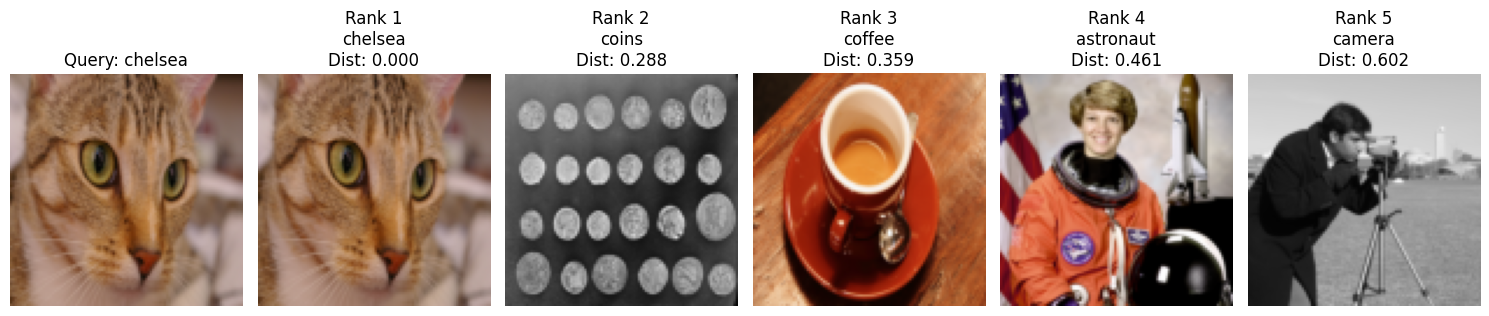

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_ubyte
from scipy.spatial import distance

# Fungsi hitung histogram
def calculate_rgb_histogram(image, bins=16):
    if image.dtype == float:
        image = img_as_ubyte(image)

    hist_r, _ = np.histogram(image[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:,:,2].ravel(), bins=bins, range=(0, 256))

    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    hist_sum = np.sum(hist_combined)

    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)  # Hindari pembagian oleh nol

    return hist_combined

# Siapkan database gambar
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:  # Jika grayscale, konversi ke RGB
            img = color.gray2rgb(img)

        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# Pilih satu citra sebagai query
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]

# Hitung jarak/kemiripan antara query dan semua citra di database
distances = [distance.cosine(query_hist, hist) for hist in database_hists]

# Urutkan citra berdasarkan jarak
sorted_indices = np.argsort(distances)

# Tampilkan hasil pencarian
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

# Tampilkan query
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for i, idx in enumerate(sorted_indices):
    img_rank = i + 1
    ax = axes[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {img_rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()

##Fitur Berbeda untuk CBIR

Processing image database...
- astronaut processed.
- camera processed.
- coffee processed.
- coins processed.
- chelsea processed.

Retrieval Results (sorted by Euclidean distance, larger distance = less similar):
Rank 1: astronaut (Euclidean Distance: 0.000)
Rank 2: chelsea (Euclidean Distance: 12.771)
Rank 3: camera (Euclidean Distance: 41.923)
Rank 4: coins (Euclidean Distance: 45.622)
Rank 5: coffee (Euclidean Distance: 52.121)


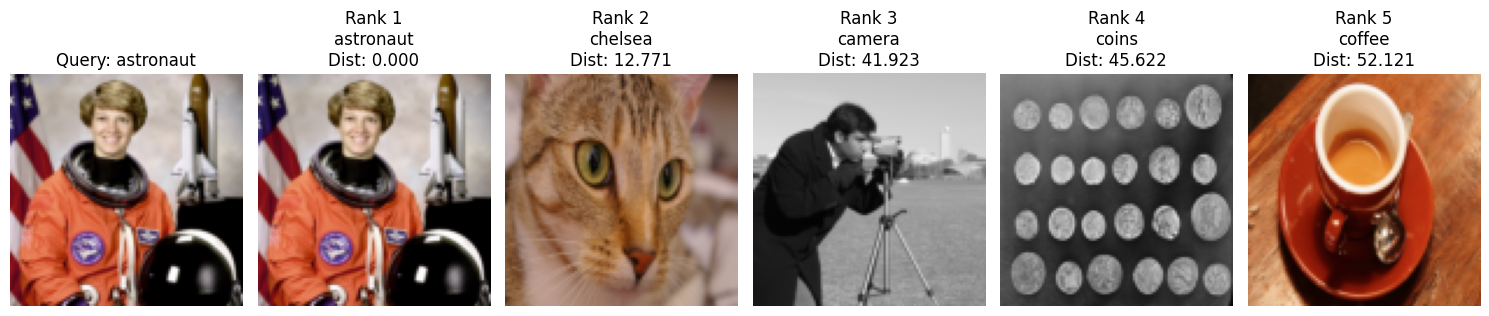

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform
from scipy.spatial import distance

def calculate_mean_rgb(image):
    if image.dtype == float:
        image = (image * 255).astype(np.uint8)

    mean_r = np.mean(image[:,:,0])
    mean_g = np.mean(image[:,:,1])
    mean_b = np.mean(image[:,:,2])

    return np.array([mean_r, mean_g, mean_b])

image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_features = []

print("Processing image database...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:
            img = color.gray2rgb(img)

        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_features.append(calculate_mean_rgb(img_resized))
        print(f"- {name} processed.")
    except Exception as e:
        print(f"Error processing {name}: {e}")

query_image_name = "astronaut"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_feature = database_features[query_index]

distances = [distance.euclidean(query_feature, feature) for feature in database_features]

sorted_indices = np.argsort(distances)

num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

print("\nRetrieval Results (sorted by Euclidean distance, larger distance = less similar):")
for i, idx in enumerate(sorted_indices):
    img_rank = i + 1
    ax = axes[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {img_rank}: {image_db_names[idx]} (Euclidean Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()

##Template Matching Invariant

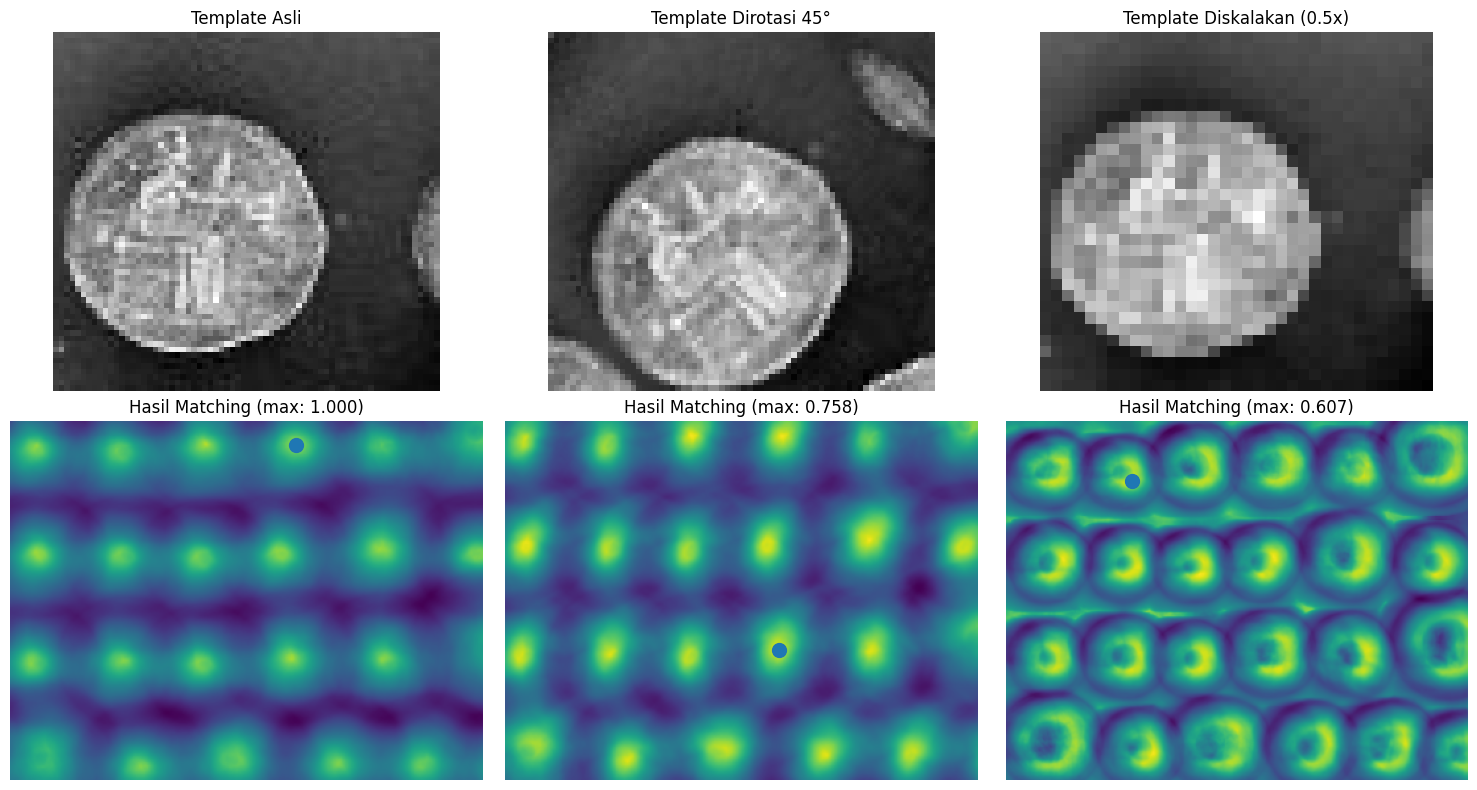

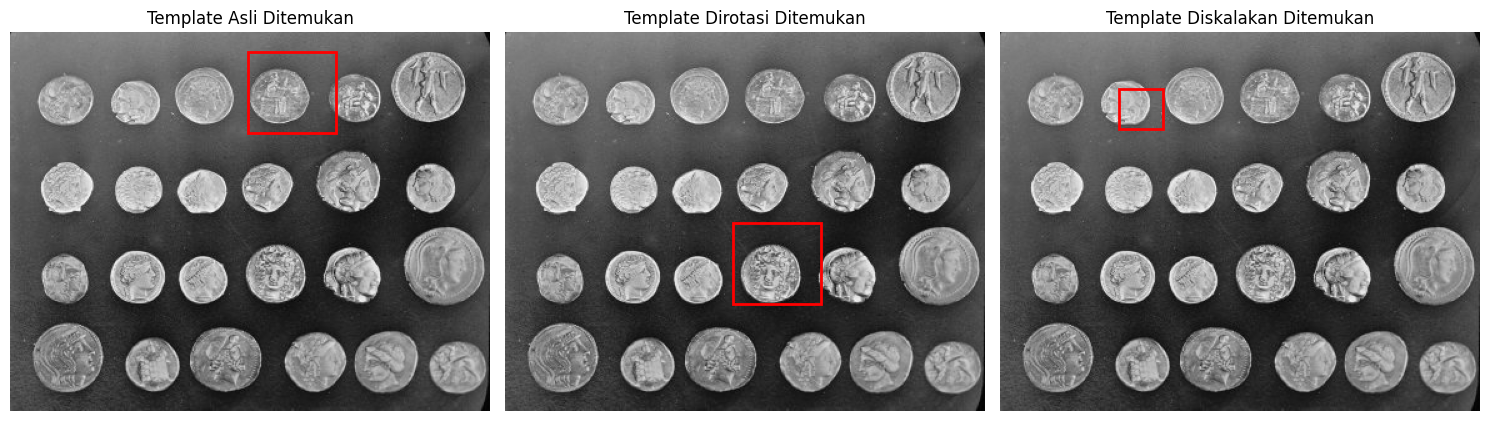

Template asli ditemukan di (x,y): (190,15)
Template dirotasi ditemukan di (x,y): (182,152)
Template diskalakan ditemukan di (x,y): (95,45)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template
from skimage.transform import rotate, rescale

image = data.coins()
template = image[15:80, 190:260]

template_rotated = rotate(template, angle=45, mode='reflect')
template_scaled = rescale(template, scale=0.5, anti_aliasing=True)

# Lakukan template matching untuk ketiga kasus
result_original = match_template(image, template)
result_rotated = match_template(image, template_rotated)
result_scaled = match_template(image, template_scaled)

ij_original = np.unravel_index(np.argmax(result_original), result_original.shape)
x_original, y_original = ij_original[::-1]
ij_rotated = np.unravel_index(np.argmax(result_rotated), result_rotated.shape)
x_rotated, y_rotated = ij_rotated[::-1]
ij_scaled = np.unravel_index(np.argmax(result_scaled), result_scaled.shape)
x_scaled, y_scaled = ij_scaled[::-1]

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# Template asli
ax[0, 0].imshow(template, cmap='gray')
ax[0, 0].set_title('Template Asli')
ax[0, 0].set_axis_off()
ax[1, 0].imshow(result_original, cmap='viridis')
ax[1, 0].set_title(f'Hasil Matching (max: {result_original.max():.3f})')
ax[1, 0].plot(x_original, y_original, 'o', markersize=10)
ax[1, 0].set_axis_off()

# Template dirotasi
ax[0, 1].imshow(template_rotated, cmap='gray')
ax[0, 1].set_title('Template Dirotasi 45°')
ax[0, 1].set_axis_off()
ax[1, 1].imshow(result_rotated, cmap='viridis')
ax[1, 1].set_title(f'Hasil Matching (max: {result_rotated.max():.3f})')
ax[1, 1].plot(x_rotated, y_rotated, 'o', markersize=10)
ax[1, 1].set_axis_off()

# Template diskalakan
ax[0, 2].imshow(template_scaled, cmap='gray')
ax[0, 2].set_title('Template Diskalakan (0.5x)')
ax[0, 2].set_axis_off()
ax[1, 2].imshow(result_scaled, cmap='viridis')
ax[1, 2].set_title(f'Hasil Matching (max: {result_scaled.max():.3f})')
ax[1, 2].plot(x_scaled, y_scaled, 'o', markersize=10)
ax[1, 2].set_axis_off()

plt.tight_layout()
plt.show()

# Visualisasi lokasi kecocokan pada gambar
fig2, ax_main = plt.subplots(1, 3, figsize=(15, 5))
for i, (x, y, template, title) in enumerate([
    (x_original, y_original, template, 'Asli'),
    (x_rotated, y_rotated, template_rotated, 'Dirotasi'),
    (x_scaled, y_scaled, template_scaled, 'Diskalakan')
]):
    ax_main[i].imshow(image, cmap='gray')
    ax_main[i].set_title(f'Template {title} Ditemukan')
    ax_main[i].set_axis_off()
    h, w = template.shape
    rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
    ax_main[i].add_patch(rect)

plt.tight_layout()
plt.show()

print(f"Template asli ditemukan di (x,y): ({x_original},{y_original})")
print(f"Template dirotasi ditemukan di (x,y): ({x_rotated},{y_rotated})")
print(f"Template diskalakan ditemukan di (x,y): ({x_scaled},{y_scaled})")